In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('Players2024.csv')
print(data.info())

data_encoded = pd.get_dummies(data, columns=['positions', 'nationality', 'Club'], drop_first=True)

scaler = StandardScaler()
data_encoded[['height_cm', 'Age']] = scaler.fit_transform(data_encoded[['height_cm', 'Age']])

data_encoded.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5935 entries, 0 to 5934
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         5935 non-null   object 
 1   birth_date   5935 non-null   object 
 2   height_cm    5935 non-null   float64
 3   positions    5935 non-null   object 
 4   nationality  5935 non-null   object 
 5   Age          5935 non-null   int64  
 6   Club         5935 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 324.7+ KB
None


,name,birth_date,height_cm,Age,positions_Defender,positions_Goalkeeper,positions_Midfield,positions_Missing,nationality_Algeria,nationality_Andorra,...,Club_Volou Neos Podosferikos Syllogos,Club_Vorskla Poltava,Club_West Ham United Football Club,Club_Willem II,Club_Wolverhampton Wanderers Football Club,Club_Yellow-Red Koninklijke Voetbalclub Mechelen,Club_ZAO FK Chornomorets Odessa,Club_Çaykur Rizespor Kulübü,Club_İstanbul Başakşehir Futbol Kulübü,"Club_Футбольный клуб ""Локомотив"" Москва"
0,James Milner,1986-01-04,-1.068025,2.805300,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Anastasios Tsokanis,1991-05-02,-0.934294,1.683021,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,Jonas Hofmann,1992-07-14,-0.934294,1.458566,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Pepe Reina,1982-08-31,0.670482,3.703124,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Lionel Carole,1991-04-12,-0.399369,1.683021,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


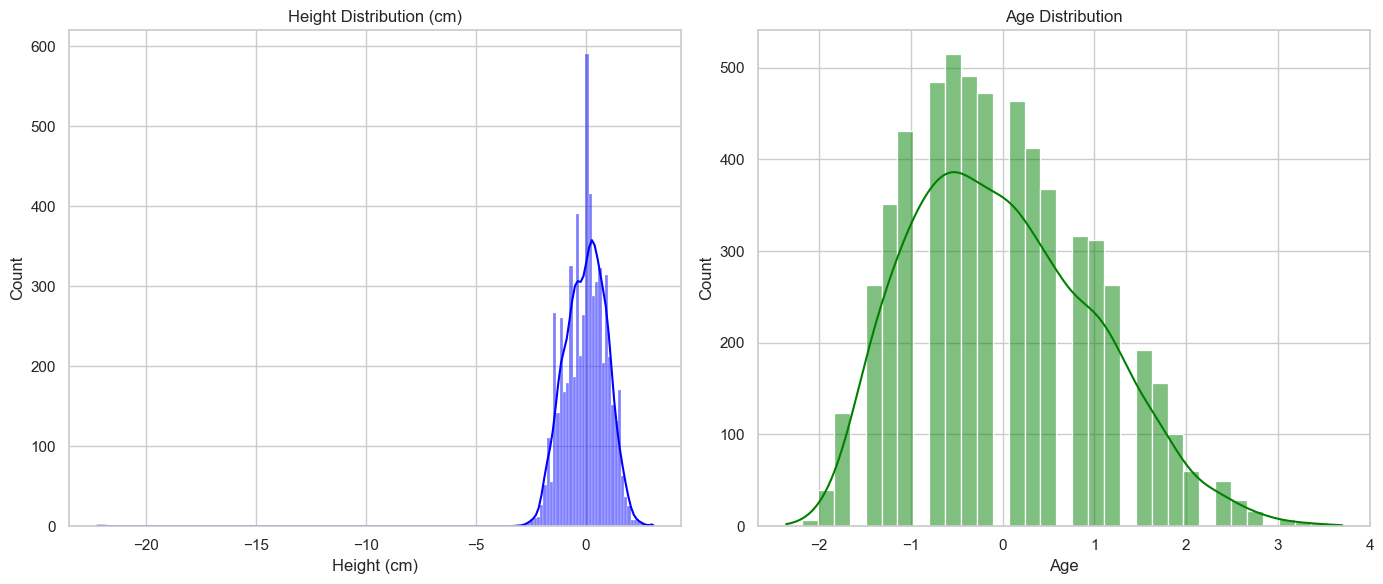

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data_encoded['height_cm'], kde=True, color='blue')
plt.title('Height Distribution (cm)')
plt.xlabel('Height (cm)')

plt.subplot(1, 2, 2)
sns.histplot(data_encoded['Age'], kde=True, color='green')
plt.title('Age Distribution')
plt.xlabel('Age')

plt.tight_layout()
plt.show()


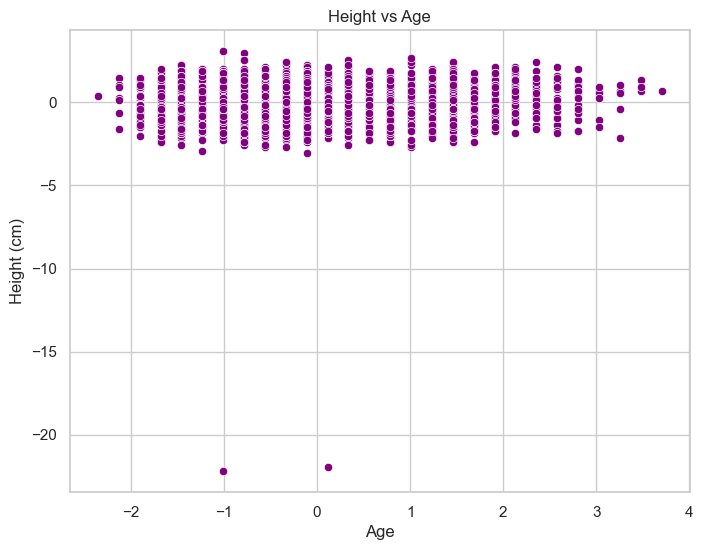

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='height_cm', data=data_encoded, color='purple')
plt.title('Height vs Age')
plt.xlabel('Age')
plt.ylabel('Height (cm)')
plt.show()



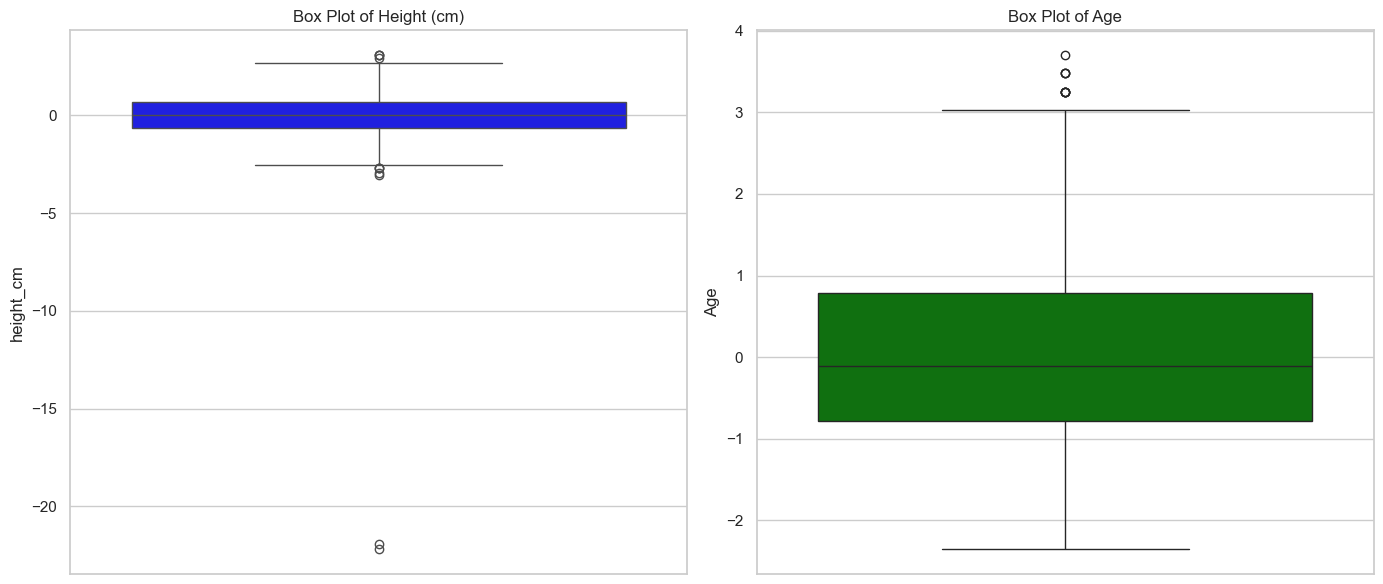

In [6]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y='height_cm', data=data_encoded, color='blue')
plt.title('Box Plot of Height (cm)')

plt.subplot(1, 2, 2)
sns.boxplot(y='Age', data=data_encoded, color='green')
plt.title('Box Plot of Age')

plt.tight_layout()
plt.show()


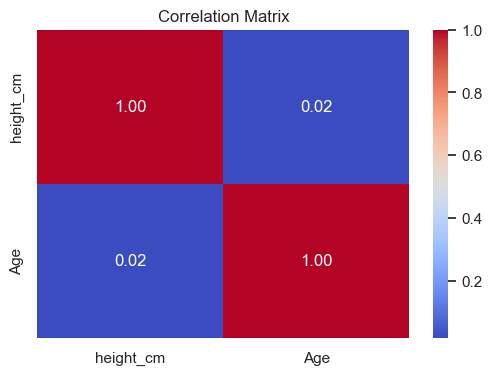

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = data_encoded[['height_cm', 'Age']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


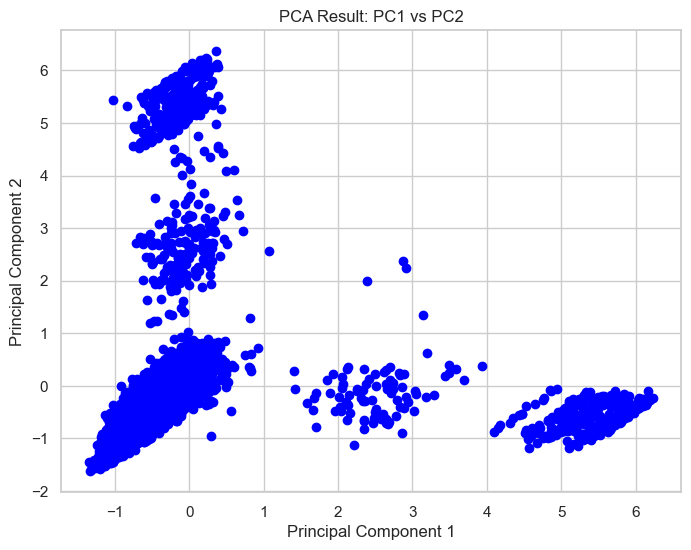

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

numeric_data = data_encoded.drop(['name', 'birth_date'], axis=1)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

pca = PCA(n_components=2)  
principal_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], color='blue')
plt.title('PCA Result: PC1 vs PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

target_column = 'positions_Defender'

X = data_encoded.drop(['name', 'birth_date', target_column], axis=1)
y = data_encoded[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)

print(f'Accuracy: {accuracy_logreg}')
print(f'Precision: {precision_logreg}')
print(f'Recall: {recall_logreg}')


Accuracy: 0.7573715248525695
Precision: 0.625
Recall: 0.6909547738693468


In [12]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)

print(f'Accuracy: {accuracy_tree}')
print(f'Precision: {precision_tree}')
print(f'Recall: {recall_tree}')


Accuracy: 0.7177759056444819
Precision: 0.5781637717121588
Recall: 0.585427135678392


In [ ]:
results = {
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_logreg, accuracy_tree],
    'Precision': [precision_logreg, precision_tree],
    'Recall': [recall_logreg, recall_tree]
}

results_df = pd.DataFrame(results)
print(results_df)


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print("\nRandom Forest Performance:")
print(f'Accuracy: {accuracy_rf}')
print(f'Precision: {precision_rf}')
print(f'Recall: {recall_rf}')

svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)

print("\nSVM Performance:")
print(f'Accuracy: {accuracy_svm}')
print(f'Precision: {precision_svm}')
print(f'Recall: {recall_svm}')

mlp = MLPClassifier(max_iter=500)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
precision_mlp = precision_score(y_test, y_pred_mlp)
recall_mlp = recall_score(y_test, y_pred_mlp)

print("\nNeural Network Performance:")
print(f'Accuracy: {accuracy_mlp}')
print(f'Precision: {precision_mlp}')
print(f'Recall: {recall_mlp}')

print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))

print("Classification Report for SVM:")
print(classification_report(y_test, y_pred_svm))

print("Classification Report for Neural Network:")
print(classification_report(y_test, y_pred_mlp))

print("\nLogistic Regression Performance:")
print(f'Accuracy: {accuracy_logreg}')
print(f'Precision: {precision_logreg}')
print(f'Recall: {recall_logreg}')

print("\nDecision Tree Performance:")
print(f'Accuracy: {accuracy_tree}')
print(f'Precision: {precision_tree}')
print(f'Recall: {recall_tree}')



Random Forest Performance:
Accuracy: 0.7363100252737995
Precision: 0.6024096385542169
Recall: 0.628140703517588

SVM Performance:
Accuracy: 0.7691659646166807
Precision: 0.6291666666666667
Recall: 0.7587939698492462

Neural Network Performance:
Accuracy: 0.7110362257792755
Precision: 0.5679012345679012
Recall: 0.5778894472361809

Classification Report for Random Forest:
              precision    recall  f1-score   support

       False       0.81      0.79      0.80       789
        True       0.60      0.63      0.62       398

    accuracy                           0.74      1187
   macro avg       0.71      0.71      0.71      1187
weighted avg       0.74      0.74      0.74      1187

Classification Report for SVM:
              precision    recall  f1-score   support

       False       0.86      0.77      0.82       789
        True       0.63      0.76      0.69       398

    accuracy                           0.77      1187
   macro avg       0.75      0.77      0.75      1

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('Players2024.csv')

data_encoded = pd.get_dummies(data, columns=['positions', 'nationality', 'Club'], drop_first=True)

scaler = StandardScaler()
data_encoded[['height_cm', 'Age']] = scaler.fit_transform(data_encoded[['height_cm', 'Age']])

data_encoded.head()


,name,birth_date,height_cm,Age,positions_Defender,positions_Goalkeeper,positions_Midfield,positions_Missing,nationality_Algeria,nationality_Andorra,...,Club_Volou Neos Podosferikos Syllogos,Club_Vorskla Poltava,Club_West Ham United Football Club,Club_Willem II,Club_Wolverhampton Wanderers Football Club,Club_Yellow-Red Koninklijke Voetbalclub Mechelen,Club_ZAO FK Chornomorets Odessa,Club_Çaykur Rizespor Kulübü,Club_İstanbul Başakşehir Futbol Kulübü,"Club_Футбольный клуб ""Локомотив"" Москва"
0,James Milner,1986-01-04,-1.068025,2.805300,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Anastasios Tsokanis,1991-05-02,-0.934294,1.683021,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,Jonas Hofmann,1992-07-14,-0.934294,1.458566,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Pepe Reina,1982-08-31,0.670482,3.703124,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Lionel Carole,1991-04-12,-0.399369,1.683021,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


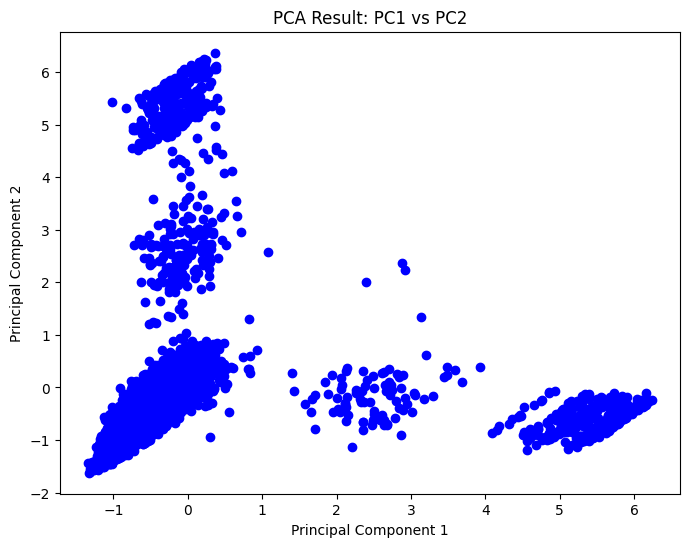

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

numeric_data = data_encoded.drop(['name', 'birth_date'], axis=1)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

pca = PCA(n_components=2) 
principal_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], color='blue')
plt.title('PCA Result: PC1 vs PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

X = data_encoded.drop(['name', 'birth_date', 'positions_Defender'], axis=1)
y = data_encoded['positions_Defender']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)

print(f'Accuracy: {accuracy_logreg}')
print(f'Precision: {precision_logreg}')
print(f'Recall: {recall_logreg}')


Accuracy: 0.7573715248525695
Precision: 0.625
Recall: 0.6909547738693468


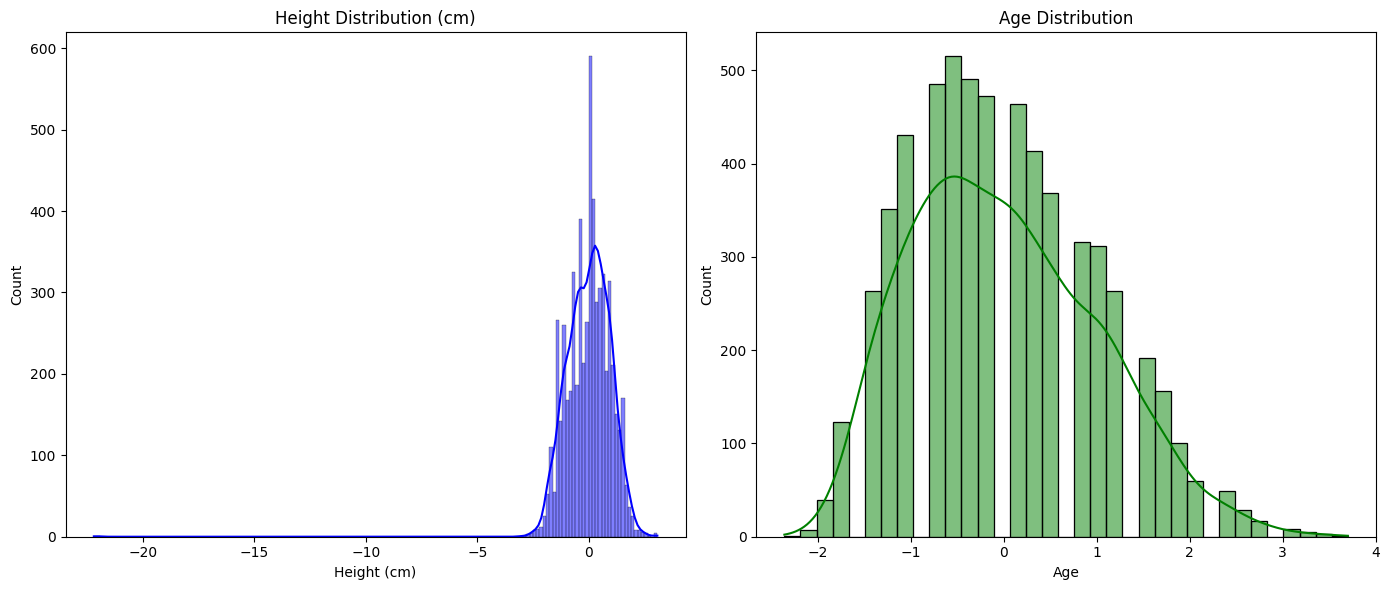

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data_encoded['height_cm'], kde=True, color='blue')
plt.title('Height Distribution (cm)')
plt.xlabel('Height (cm)')

plt.subplot(1, 2, 2)
sns.histplot(data_encoded['Age'], kde=True, color='green')
plt.title('Age Distribution')
plt.xlabel('Age')

plt.tight_layout()
plt.show()


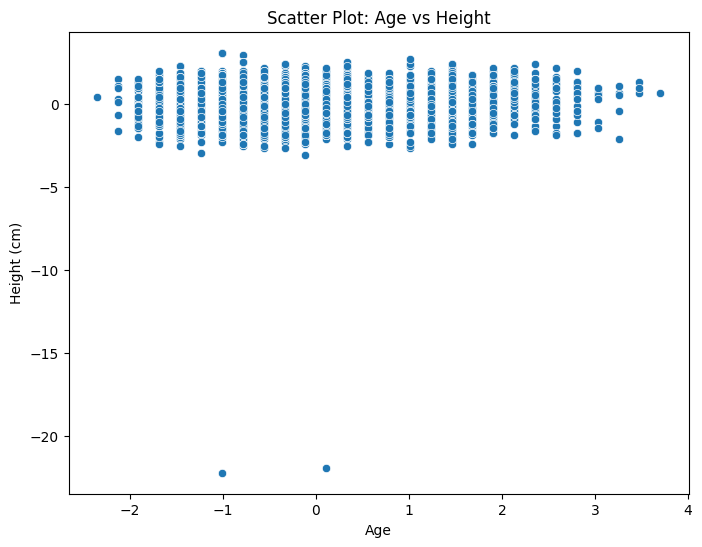

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='height_cm', data=data_encoded)
plt.title('Scatter Plot: Age vs Height')













plt.xlabel('Age')
plt.ylabel('Height (cm)')
plt.show()


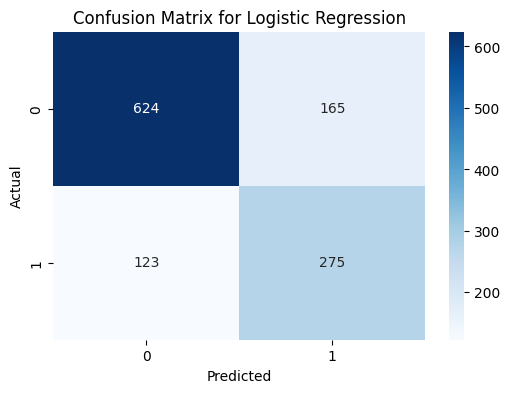

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
